# Monte Carlo simulation
Imagine you are asked to estimate the average distance between randomly placed points within a unit square (see figure below). Describe the python workflow that you would use to estimate the average distance between two randomly placed points within the unit square.
Physically, the average distance is important when studying particle collisions, if it's smaller they will collide more; the mean free path (how much they travel before encountering another particle). It could also tell us how much vacuum is contained in the box.

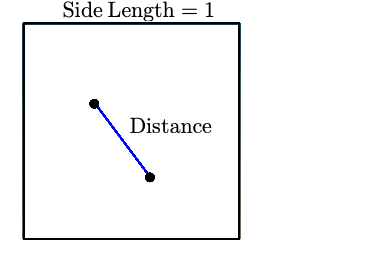

$\langle d \rangle $ = ?

* **Domain**: Unit square.
* **Deterministic approach**: Euclidean distances.
* **Create a stochastic sample of particles with random ($x_i, y_i$).**
* **Simulate iteratively for a large number of particles N.**

**Obs.** $0 < \langle d \rangle  \leq \sqrt{Lx² + Ly²} = \sqrt{2}$

In [1]:
#Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

### 1) Construct the unit square domain and populate it with random particles.

In [2]:
# Number of particles
N = 10

# Random numbers for the particle positions
numbers = np.random.rand(2*N)
#print(numbers.shape)

# Random (x,y) positions
particles = numbers.reshape(N, 2)
#print(particles.shape)

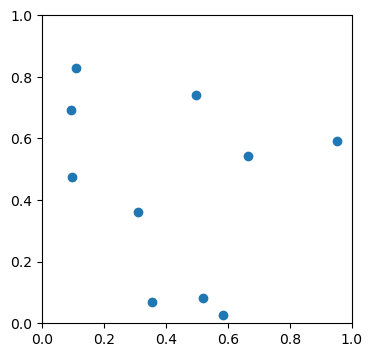

In [3]:
# Plotting the particles inside the domain
plt.figure(figsize = (4, 4))
plt.scatter(particles[:, 0], particles[:, 1]) #select first column for x and second for y coordinates
# Domain
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.show()

### 2) Estimate distances.
Be careful with not calculating the distance between two particles multiple times.

#### Only consecutive particles:

In [4]:
# Empty list to store the distances
d_list = []

# Loop over all particles
for j in range(particles.shape[0] - 1):
    #print(j)
    # Delta x
    delta_x = particles[j + 1][0] - particles[j][0]
    # Delta y
    delta_y = particles[j + 1][1] - particles[j][1]
    # Overall distance
    d_list.append(np.sqrt(delta_x**2 + delta_y**2))
    
# Convert the list to an array
d_list = np.array(d_list)

#print(d_list.shape)

### 3) Average distance considering particles at random positions.

In [5]:
# Mean distance
m_d = np.mean(d_list)

print(m_d)

0.5581163222098069


### 4) Aggregate the results and study convergence.

In [6]:
def mean_distance(N, s):
    """
    Input:
    N -> Number of particles
    s -> Random generator seed

    Output:
    m_d -> Mean distance between particles
    """
    # Fix seed:
    np.random.seed(s)
        
    # Random number for the particle positions
    numbers = np.random.rand(2*N)
    
    #print(numbers.shape)
    # Random (x, y) Positions
    particles = numbers.reshape(N,2)

    # Empty list to store distances
    d_list = []

    # Loop over all particles

    for j in range(particles.shape[0] - 1):
    
        #print(j)
        # Delta x
        delta_x = particles[j + 1][0] - particles[j][0]
        # Delta y
        delta_y = particles[j + 1][1] - particles[j][1]
    
        # Overall Euclidean distance
        d_list.append(np.sqrt(delta_x**2 + delta_y**2))
    
    d_list = np.array(d_list)

    # Mean distance
    m_d = np.mean(d_list)

    return m_d

In [7]:
# Double checking
mean_distance(100, 123)

0.5146923148978282

### 5) Iteration over two seeds:

In [8]:
# Seeds 
seed_1 = 123
seed_2 = 1427

# Empty lists:
n_list = []
m_list1 = []
m_list2 = []

# Global samples
k = 25

# For loop
for j in range(1,k+1):
    n_list.append(2**j)
    m_list1.append(mean_distance(2**j, seed_1))
    m_list2.append(mean_distance(2**j, seed_2))

# Convert to arrays
n_list = np.array(n_list)
m_list1 = np.array(m_list1)
m_list2 = np.array(m_list2)

In [9]:
print(n_list.shape, m_list1.shape, m_list2.shape)

(25,) (25,) (25,)


### 6) Convergence plot:

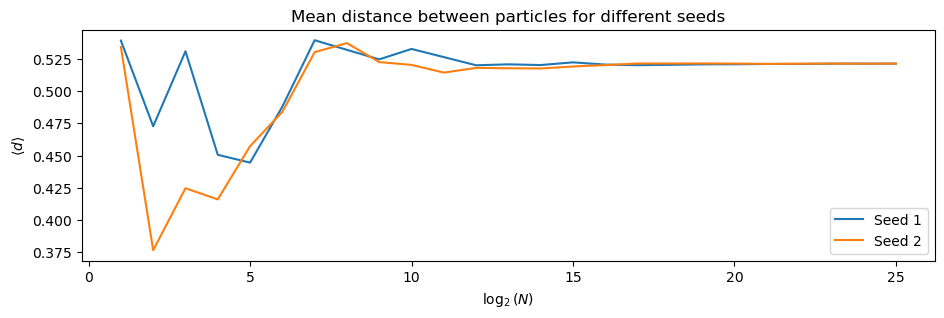

In [10]:
plt.figure(figsize=(11,3))

plt.plot(np.log2(n_list), m_list1, label = "Seed 1")
plt.plot(np.log2(n_list), m_list2, label = "Seed 2")
plt.legend()
plt.title("Mean distance between particles for different seeds")

plt.xlabel(r"$\log_2(N)$")
plt.ylabel(r"$\langle d \rangle$")

plt.show()

### 5.1) Second manner:

In [11]:
def mean_distance_2(N, s):
    """
    Input:
    N -> Number of particles
    s -> Random generator seed
    """
    # Fix seed:
    np.random.seed(s)
        
    # Random number for the particle positions
    part_left  = np.random.random((N, 2))
    part_right = np.random.random((N, 2))

    # Empty list to store distances
    d_part = np.sqrt(np.sum((part_left - part_right)**2, axis = 1))

    # Mean distance
    m_d = np.mean(d_part)

    return m_d

In [12]:
# Safe check
mean_distance_2(100, 123)

0.511517813683912

In [13]:
# Seeds 
seed_3 = 123456675
seed_4 = 1090389

# Empty lists:
n_list = []
m_list3 = []
m_list4 = []

# Global samples
k = 25

# For loop
for j in range(1,k+1):
    n_list.append(2**j)
    m_list3.append(mean_distance_2(2**j, seed_3))
    m_list4.append(mean_distance_2(2**j, seed_4))

# Convert to arrays
n_list = np.array(n_list)
m_list3 = np.array(m_list3)
m_list4 = np.array(m_list4)

### 6.1) Convergence plot:

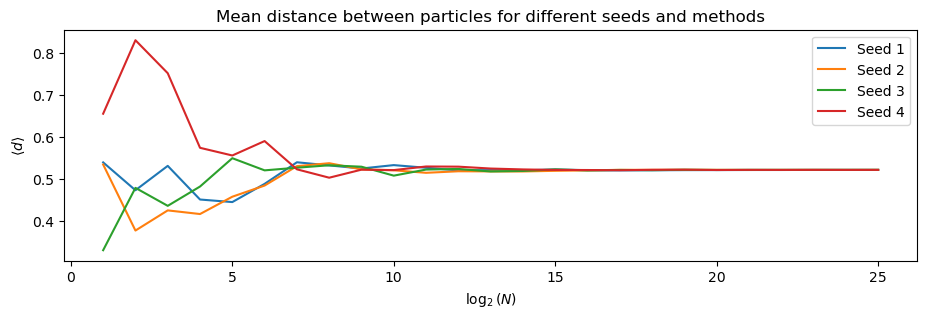

In [14]:
plt.figure(figsize=(11,3))

#Method 1
plt.plot(np.log2(n_list), m_list1, label = "Seed 1")
plt.plot(np.log2(n_list), m_list2, label = "Seed 2")
#Method 2
plt.plot(np.log2(n_list), m_list3, label = "Seed 3")
plt.plot(np.log2(n_list), m_list4, label = "Seed 4")

plt.legend()
plt.title("Mean distance between particles for different seeds and methods")
plt.xlabel(r"$\log_2(N)$")
plt.ylabel(r"$\langle d \rangle$")

plt.show()